In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import LieTrotter
from scipy.linalg import expm
from scipy.linalg import norm
import numpy as np
# customize quantum circuit for quantum simulation 
from qiskit import QuantumRegister
from qiskit.circuit.library import RZZGate, RXGate
from qiskit import transpile
from qiskit import qasm2, qasm3
import qiskit.version

print("Qiskit version:", qiskit.version.get_version_info())

# 参数
n = 5       # 自旋数
J = 0.5     # 相互作用强度
h = 1.0     # 横场强度
t = 1     # 演化时间

# 定义 Pauli 矩阵
X = np.array([[0, 1], [1, 0]])  # Pauli-X 矩阵
Y = np.array([[0, -1j], [1j, 0]])  # Pauli-Y 矩阵
Z = np.array([[1, 0], [0, -1]])  # Pauli-Z 矩阵
I = np.eye(2)  # 单位矩阵


# 生成五比特的 Ising 模型哈密顿量
def ising_hamiltonian(num_bits, J=0.5, h=1):
    H1 = np.zeros((2**num_bits, 2**num_bits), dtype=complex)
    H2 = np.zeros((2**num_bits, 2**num_bits), dtype=complex)
    H3 = np.zeros((2**num_bits, 2**num_bits), dtype=complex)
    
    # 添加最近邻自旋的交互作用 (σz σz)
    for i in range(0, num_bits - 1, 2):  # 只考虑相邻自旋，不包含周期性边界
        # 生成针对 (i, i+1) 对的 σz σz 交互项
        # Heisenberg 模型的交互作用项可以是 σx σx, σy σy 或 σz σz
        interaction_term = np.kron(np.eye(2**i), np.kron(np.kron(Z, Z), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(X, X), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(Y, Y), np.eye(2**(num_bits-i-2))))
        H3 += -J * interaction_term
    
    for i in range(1, num_bits - 1, 2):
        # 生成针对 (i, i+1) 对的 σz σz 交互项
        interaction_term = np.kron(np.eye(2**i), np.kron(np.kron(Z, Z), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(X, X), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(Y, Y), np.eye(2**(num_bits-i-2))))
        H2 += -J * interaction_term
        
    # 添加外部磁场项 (σx)s
    for i in range(num_bits):
        field_term = np.kron(np.eye(2**i), np.kron(X, np.eye(2**(num_bits-i-1))))
        H1 += -h * field_term
        
    return H1, H2, H3, H1 + H2 + H3

H1, H2, H3, H = ising_hamiltonian(n, J, h)
np.save('Ising_Hamiltonian.npy', H)
U = expm(-1j * H * t)

# spectral norm of U
norm(U, ord=2)

Qiskit version: 1.4.2


np.float64(1.0000000000000004)

In [2]:
r_scale = 2  # Trotter 步数缩放因子
r_list = []

choice = 'well'

if choice == 'well':
    r_list = r_scale * np.array([1, 2, 6])
    b_list = [1/105, -1/6, 81/70]

    r_list = r_scale * np.array([1, 2, 3, 10])
    b_list = [-1/2376, 2/45, -729/3640, 31250/27027]

    r_list = r_scale * np.array([1, 2, 3, 5, 17])
    b_list = [1/165888, -256/89775, 6561/179200, -390625/2128896, 6975757441/6067353600]
    
    m = len(r_list)  # Interpolation number
    s_list = t / np.array(r_list) # 每个 Trotter 步的演化时间
    
else:
    eta = 2.0  # 外插叠加系数
    m = 3 # Interpolation number
    for i in range(1, m + 1):
        # 计算 Trotter 步数
        r = r_scale * np.ceil((np.sqrt(8) * m / np.pi) / np.sin(np.pi * (2 * i - 1) / (8 * m)))
        r_list.append(int(r))
        r_list.reverse()

    s_list = t / np.array(r_list) # 每个 Trotter 步的演化时间

    b_list = np.ones(m)  # 外插叠加系数

    for i in range(m):
        for j in range(m):
            if j != i:
                b_list[i] *= s_list[j]**eta / (s_list[j]**eta - s_list[i]**eta)

print('Trotter Step:', r_list)
print('Coefficients:', b_list)

Trotter Step: [ 2  4  6 10 34]
Coefficients: [6.028163580246913e-06, -0.0028515733778891675, 0.036612723214285714, -0.18348712196368447, 1.1497199439637076]


In [ ]:
#替换为你的toke账号
token = "#copy your token provided by https://quantum.ibm.com/#"
cloudrun = 'False'

if cloudrun == 'True':
  from qiskit_ibm_runtime import QiskitRuntimeService
  
  QiskitRuntimeService.save_account(
    token=token,
    channel="ibm_quantum",
    overwrite=True # `channel` distinguishes between different account types
  )

  from qiskit import QuantumCircuit
  from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
  from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
  
  service = QiskitRuntimeService()

  # select the least busy machine
  backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

Trotter step: 2
Simulation error between final state:  0.07720953381974154
Overlap between final state:  0.9974043695986802
Trotter step: 4
Simulation error between final state:  0.01782831345550471
Overlap between final state:  0.9998593479786642
Trotter step: 6
Simulation error between final state:  0.007812914349923707
Overlap between final state:  0.9999729128872094
Trotter step: 10
Simulation error between final state:  0.0027926474290980437
Overlap between final state:  0.9999965344068216
Trotter step: 34
Simulation error between final state:  0.00024069870984703347
Overlap between final state:  0.9999999742366351


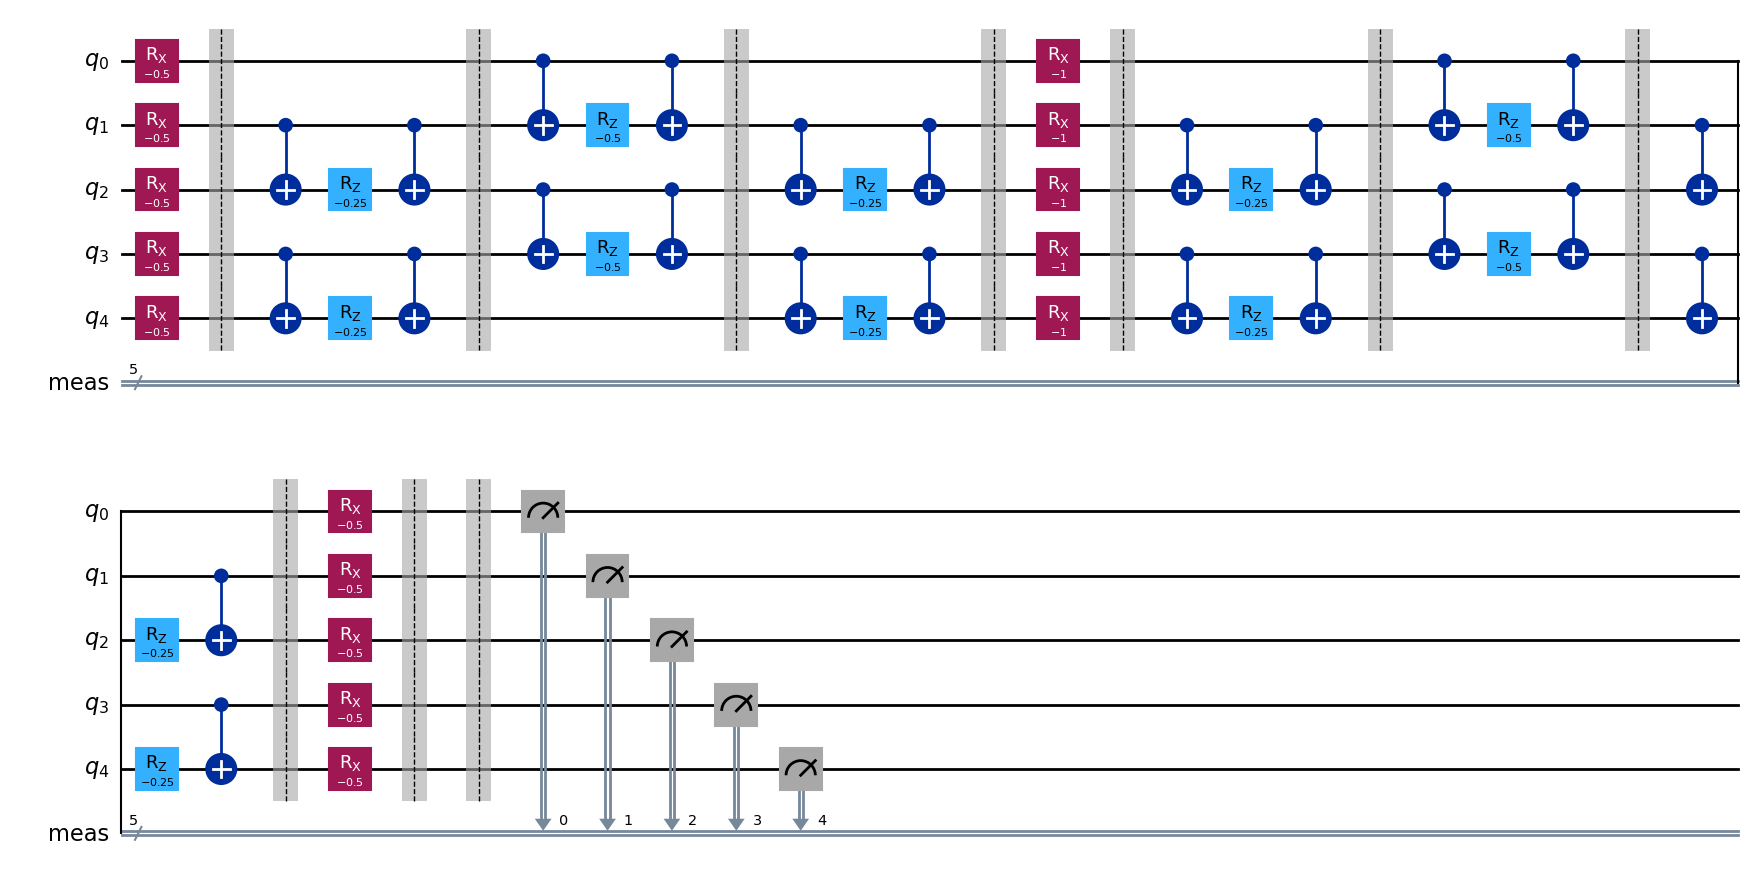

In [5]:
qc_list = []  # 量子电路列表

for r in r_list:
    # 创建一个有 5 个量子比特的寄存器
    qreg = QuantumRegister(5, 'q')
    qc = QuantumCircuit(qreg)
    for i in range(r):
        rx_angle = - h * t / r
        if i == 0:
            qc.append(RXGate(rx_angle), [qreg[0]])
            qc.append(RXGate(rx_angle), [qreg[1]])
            qc.append(RXGate(rx_angle), [qreg[2]])
            qc.append(RXGate(rx_angle), [qreg[3]])
            qc.append(RXGate(rx_angle), [qreg[4]])
            qc.barrier()
        
        zz_angle = - J * t / r
        # 添加一层 ZZ(-0.05) 门
        qc.append(RZZGate(zz_angle), [qreg[1], qreg[2]])
        qc.append(RZZGate(zz_angle), [qreg[3], qreg[4]])
        qc.barrier()
        
        # 合并一层 ZZ(-0.05) 门
        qc.append(RZZGate(2 * zz_angle), [qreg[0], qreg[1]])
        qc.append(RZZGate(2 * zz_angle), [qreg[2], qreg[3]])
        qc.barrier()
        
        # 添加一层 ZZ(-0.05) 门
        qc.append(RZZGate(zz_angle), [qreg[1], qreg[2]])
        qc.append(RZZGate(zz_angle), [qreg[3], qreg[4]])
        qc.barrier()
        
        
        # 合并层 RX(-0.1) 门
        if i == r - 1:
            qc.append(RXGate(rx_angle), [qreg[0]])
            qc.append(RXGate(rx_angle), [qreg[1]])
            qc.append(RXGate(rx_angle), [qreg[2]])
            qc.append(RXGate(rx_angle), [qreg[3]])
            qc.append(RXGate(rx_angle), [qreg[4]])
            qc.barrier()
        else:
            qc.append(RXGate(2 * rx_angle), [qreg[0]])
            qc.append(RXGate(2 * rx_angle), [qreg[1]])
            qc.append(RXGate(2 * rx_angle), [qreg[2]])
            qc.append(RXGate(2 * rx_angle), [qreg[3]])
            qc.append(RXGate(2 * rx_angle), [qreg[4]])
            qc.barrier()
        

    # 转换电路以适应特定的量子设备
    qc = transpile(qc, basis_gates=['rz', 'rx', 'cx'])
    qc_list.append(qc)
     
    # 展开电路并导出为 QASM 文件
    dump = 2
    
    if dump == 2:
        with open(f"./qasm/qasm2/Ising_r_{r}.qasm", "w") as f:
            f.write(qasm2.dumps(qc))
    elif dump == 3:
        with open(f"./qasm/qasm3/Ising_r_{r}.qasm", "w") as f:
            f.write(qasm3.dumps(qc))
    
# 创建一个初始态，这里以 |0...1⟩ 初始态为例
initial_state = Statevector.from_label('0' * (n - 1) + '1') 
psi0 = initial_state.data

# print("initial error: ", np.linalg.norm(initial_state.data - psi0), end ='\n')
# 演化：ψ(t) = e^{-iHt} ψ(0)
psi_t = U @ psi0

# 计算每个 Trotter 步数下的最终态
for i in range(len(qc_list)):
    r = r_list[i]
    qc = qc_list[i]
    # 使用 evolve 方法计算最终态
    final_state = initial_state.evolve(qc)
    print(f"Trotter step: {r}") # , {final_state.data[0]}")
    print(f'Simulation error between final state: ', np.linalg.norm(final_state.data - psi_t), end ='\n')
    print(f'Overlap between final state: ', np.abs(np.vdot(final_state.data, psi_t)), end ='\n')

    qc.measure_all()
    # pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    # isa_circuit = pm.run(qc)
    # 
    # sampler = Sampler(backend)
    # job = sampler.run([isa_circuit])
    # result = job.result()
    # print(f" > Counts: {result[0].data.meas.get_counts()}")
    
qc_list[0].draw('mpl')

Trotter step: 2
Simulation error between final state:  0.0772095338197415
Overlap between final state:  0.9974043695986806
Trotter step: 4
Simulation error between final state:  0.01782831345550479
Overlap between final state:  0.9998593479786642
Trotter step: 6
Simulation error between final state:  0.007812914349923575
Overlap between final state:  0.9999729128872106
Trotter step: 10
Simulation error between final state:  0.00279264742909826
Overlap between final state:  0.9999965344068209
Trotter step: 34
Simulation error between final state:  0.0002406987098468164
Overlap between final state:  0.9999999742366307


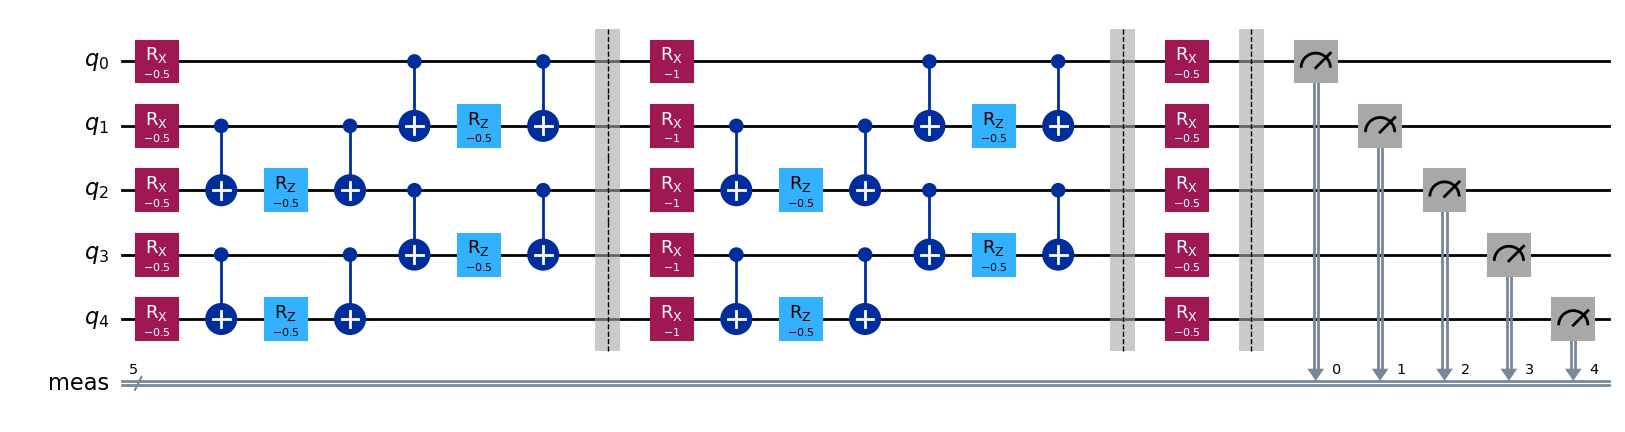

In [6]:
# Quantum Circuit after Optimization
qc_list = []  # 量子电路列表

for r in r_list:
    # 创建一个有 5 个量子比特的寄存器
    qreg = QuantumRegister(5, 'q')
    qc = QuantumCircuit(qreg)
    for i in range(r):
        rx_angle = - h * t / r
        if i == 0:
            qc.append(RXGate(rx_angle), [qreg[0]])
            qc.append(RXGate(rx_angle), [qreg[1]])
            qc.append(RXGate(rx_angle), [qreg[2]])
            qc.append(RXGate(rx_angle), [qreg[3]])
            qc.append(RXGate(rx_angle), [qreg[4]])
        
        zz_angle = - J * t / r
        # 添加一层 ZZ(-0.05) 门
        qc.append(RZZGate(2 * zz_angle), [qreg[1], qreg[2]])
        qc.append(RZZGate(2 * zz_angle), [qreg[3], qreg[4]])
        
        # 合并一层 ZZ(-0.05) 门
        qc.append(RZZGate(2 * zz_angle), [qreg[0], qreg[1]])
        qc.append(RZZGate(2 * zz_angle), [qreg[2], qreg[3]])
        qc.barrier()
        
        
        # 合并层 RX(-0.1) 门
        if i == r - 1:
            qc.append(RXGate(rx_angle), [qreg[0]])
            qc.append(RXGate(rx_angle), [qreg[1]])
            qc.append(RXGate(rx_angle), [qreg[2]])
            qc.append(RXGate(rx_angle), [qreg[3]])
            qc.append(RXGate(rx_angle), [qreg[4]])
        else:
            qc.append(RXGate(2 * rx_angle), [qreg[0]])
            qc.append(RXGate(2 * rx_angle), [qreg[1]])
            qc.append(RXGate(2 * rx_angle), [qreg[2]])
            qc.append(RXGate(2 * rx_angle), [qreg[3]])
            qc.append(RXGate(2 * rx_angle), [qreg[4]])
        

    # 转换电路以适应特定的量子设备
    qc = transpile(qc, basis_gates=['rz', 'rx', 'cx'])
    qc_list.append(qc)

    # 展开电路并导出为 QASM 文件
    dump = 2
    
    if dump == 2:
        with open(f"./qasm/qasm2/Opt_Ising_r_{r}.qasm", "w") as f:
            f.write(qasm2.dumps(qc))
    elif dump == 3:
        with open(f"./qasm/qasm3/Opt_Ising_r_{r}.qasm", "w") as f:
            f.write(qasm3.dumps(qc))
    

# 创建一个初始态，这里以 |0...1⟩ 初始态为例
initial_state = Statevector.from_label('0' * (n - 1) + '1') 
psi0 = initial_state.data

# print("initial error: ", np.linalg.norm(initial_state.data - psi0), end ='\n')
# 演化：ψ(t) = e^{-iHt} ψ(0)
psi_t = U @ psi0

# 计算每个 Trotter 步数下的最终态
for i in range(len(qc_list)):
    r = r_list[i]
    qc = qc_list[i]
    # 使用 evolve 方法计算最终态
    final_state = initial_state.evolve(qc)
    print(f"Trotter step: {r}") # , {final_state.data[0]}")
    print(f'Simulation error between final state: ', np.linalg.norm(final_state.data - psi_t), end ='\n')
    print(f'Overlap between final state: ', np.abs(np.vdot(final_state.data, psi_t)), end ='\n')

    qc.measure_all()
    # pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    # isa_circuit = pm.run(qc)
    # 
    # sampler = Sampler(backend)
    # job = sampler.run([isa_circuit])
    # result = job.result()
    # print(f" > Counts: {result[0].data.meas.get_counts()}")
    
qc_list[0].draw('mpl') #, initial_state=True)

In [ ]:
# 定义全局和局部磁化算符
# qiskit 里的 q 顺序是反的，所以这里的 Z 其实作用在 q_4 上
local_mag = np.kron(Z, np.kron(I, np.kron(I, np.kron(I, I))))  
global_mag = np.kron(Z, np.kron(Z, np.kron(Z, np.kron(Z, Z))))  # Z^5

# 创建一个初始态，这里以 |0...1⟩ 初始态为例
initial_state = Statevector.from_label('0' * (n - 1) + '1') 
psi0 = initial_state.data

# 演化：ψ(t) = e^{-iHt} ψ(0)
psi_t = U @ psi0

# np.vdot(psi0, np.dot(local_mag, psi0))
print("ideal local magnetization:", np.abs(np.vdot(psi_t, np.dot(local_mag, psi_t))))

def Trotter_Unitary(r):
    U_r = expm(-1j * H1 * t / (2 * r)) @ expm(-1j * H2 * t / (2 * r)) @ expm(-1j * H3 * t / r) @ expm(-1j * H2 * t / (2 * r)) @ expm(-1j * H1 * t / (2 * r))
    U = np.identity(2**n, dtype=complex)
    for i in range(r):
        U = U @ U_r
    return U

sum_l = 0
for i in range(len(r_list)):
    psi_matrix = Trotter_Unitary(r_list[i]) @ psi0
    observable = np.vdot(psi_matrix, np.dot(local_mag, psi_matrix))
    # print(norm(Trotter_Unitary(r_list[i])- expm(-1j * H * t), ord=2), end ='\n')
    print(f"r = {r_list[i]}, exact local magnetization: {np.abs(observable)}")
    sum_l += b_list[i] * np.abs(observable)
    
print(f"MPF ideal local magnetization: {sum_l}")

# 这里和下面不一样是因为 t 被换成了 1.0, 0.1 的时候才是 0.99 几

ideal local magnetization: 0.3107385662547188
r = 2, ideal local magnetization: 0.27237742885542743
r = 4, ideal local magnetization: 0.3018250671631699
r = 6, ideal local magnetization: 0.3068279508485742
r = 10, ideal local magnetization: 0.30933994455895336
r = 34, ideal local magnetization: 0.31061798293314946
MPF ideal local magnetization: 0.3107385662447123


In [74]:
import pickle

save_filename = f'./results/nspin{n}.pickle'

with open(save_filename, 'rb') as f:
        pickle_list = pickle.load(f)

[counts_dict_list_list]=pickle_list

for key, value in counts_dict_list_list[0].items():
    basis = Statevector.from_label(key).data
    # print(np.abs(np.vdot(basis, np.dot(global_mag, basis))))

# np.vdot(psi0, np.dot(local_mag, psi0))
print("ideal local magnetization:", np.abs(np.vdot(psi_t, np.dot(local_mag, psi_t))))

sum_l = 0
sum_g = 0
for i in range(len(r_list)):
    l = 0
    g = 0
    for key, value in counts_dict_list_list[i].items():
        basis = Statevector.from_label(key).data
        l += int(value)/2000 * np.vdot(basis, np.dot(local_mag, basis))
        g += int(value)/2000 * np.vdot(basis, np.dot(global_mag, basis))
        
    print(f"r = {r_list[i]} local magnetization: {np.abs(l)}") #, error=", (l - np.vdot(psi_t, np.dot(local_mag, psi_t))))
    # print(f"r = {r_list[i]} global magnetization: {g}, error=", (g - np.vdot(psi_t, np.dot(global_mag, psi_t))))
    
    sum_l += b_list[i] * l
    sum_g += b_list[i] * g
    
print("MPF local magnetization:", np.abs(sum_l)) #, error=", (sum_l - np.vdot(psi_t, np.dot(local_mag, psi_t))))

# print("ideal global magnetization:", np.vdot(psi_t, np.dot(global_mag, psi_t)))
# 
# sum_l = 0
# sum_g = 0
# for i in range(len(r_list)):
#     l = 0
#     g = 0
#     for key, value in counts_dict_list_list[i].items():
#         basis = Statevector.from_label(key).data
#         l += int(value)/2000 * np.vdot(basis, np.dot(local_mag, basis))
#         g += int(value)/2000 * np.vdot(basis, np.dot(global_mag, basis))
#         
#     print(f"r = {r_list[i]} global magnetization: {np.abs(g)}") #, error=", (g - np.vdot(psi_t, np.dot(global_mag, psi_t))))
#     
#     sum_l += b_list[i] * l
#     sum_g += b_list[i] * g
#     
# print("MPF global magnetization:", np.abs(sum_g)) #, ", error=", (sum_g - np.vdot(psi_t, np.dot(global_mag, psi_t))))

ideal local magnetization: 0.31073856625471924
r = 2 local magnetization: 0.9049999999999998
r = 4 local magnetization: 0.8780000000000002
r = 6 local magnetization: 0.852
r = 10 local magnetization: 0.8160000000000002
r = 34 local magnetization: 0.488
MPF local magnetization: 0.44003365537274763


In [6]:
print("ideal local magnetization:", np.abs(np.vdot(psi_t, np.dot(local_mag, psi_t))))

zne_l = np.array([0.96693853, 0.9604065, 0.95237299, 0.93611246, 0.836295])
for i in range(len(r_list)):
    print(f"r = {r_list[i]} local magnetization after ZNE: {zne_l[i]}") #, error=", (zne_l[i] * sum_l - np.vdot(psi_t, np.dot(local_mag, psi_t))))

print("MPF local magnetization after ZNE:", np.vdot(zne_l, b_list))

ideal local magnetization: 0.9800831724056154
r = 2 local magnetization after ZNE: 0.96693853
r = 4 local magnetization after ZNE: 0.9604065
r = 6 local magnetization after ZNE: 0.95237299
r = 10 local magnetization after ZNE: 0.93611246
r = 34 local magnetization after ZNE: 0.836295
MPF local magnetization after ZNE: 0.8218765873532949
